# Predicción de Abandono Escolar y Éxito Académico
### Universidad Nacional — Sede Regional Brunca, Campus Pérez Zeledón
**Curso:** Inteligencia Artificial  
**Profesor:** Pablo Andrés Venegas Elizondo  
**Integrantes:** Altamirano Cordero Deyaneira, Mata Flores Yenifer, Ortiz Molina Jordan

**Fecha:** Junio 2026


## 1. Introducción y Planteamiento del Problema


### 1.1 Introducción

El abandono escolar universitario es un problema que afecta a instituciones 
educativas de todo el mundo. No todos los estudiantes que inician una carrera 
logran terminarla, y las causas pueden ser muy diversas: dificultades 
económicas, bajo rendimiento académico, problemas personales o una combinación 
de estos factores.

Tradicionalmente, detectar a un estudiante en riesgo dependía de la 
experiencia del personal académico o de que el problema ya fuera visible — 
muchas veces demasiado tarde para intervenir efectivamente.

La Inteligencia Artificial, específicamente el aprendizaje automático 
(Machine Learning), ofrece una alternativa: analizar patrones en datos 
históricos de estudiantes para predecir, de forma temprana, cuáles tienen 
mayor probabilidad de abandonar. Esto le permite a la institución actuar 
antes de que el abandono ocurra, ya sea mediante apoyo económico, tutoría 
académica u orientación personalizada.

Este proyecto desarrolla un sistema de clasificación que predice si un 
estudiante va a abandonar su carrera, continuar matriculado o graduarse, 
funcionando como una herramienta de apoyo a la toma de decisiones 
institucionales.

### 1.1 Contexto del Dataset

Se utiliza un conjunto de datos proveniente de una institución de educación 
superior de Portugal, creado a partir de múltiples bases de datos 
institucionales y puesto a disposición pública en diciembre de 2021 a través 
del repositorio UCI Machine Learning Repository.

El dataset contiene información de estudiantes matriculados en distintas 
titulaciones de grado: agronomía, diseño, educación, enfermería, periodismo, 
administración, servicios sociales y tecnologías, entre otras.

Los datos capturan tres tipos de información:
- **Trayectoria académica previa** al ingreso
- **Factores demográficos y socioeconómicos** del estudiante
- **Rendimiento académico** al finalizar el primer y segundo semestre

### 1.2 Definición del Problema

El problema se formula como una tarea de **clasificación supervisada 
multiclase**. A partir de información demográfica, socioeconómica y del 
rendimiento académico del primer y segundo semestre, el modelo predice 
la situación final del estudiante en una de tres categorías:

- **Dropout**: el estudiante abandonó la carrera
- **Enrolled**: el estudiante continúa matriculado activo
- **Graduate**: el estudiante completó y se graduó

**Variables de entrada (features):** las 36 características del dataset,
que incluyen datos demográficos, socioeconómicos y rendimiento académico
de los dos primeros semestres.

**Variable de salida (target):** la columna `Target`, que indica la 
situación final del estudiante.

**Objetivo del modelo:** predecir la categoría más probable para un 
estudiante dado, con el fin de identificar tempranamente casos de riesgo 
de abandono y apoyar la toma de decisiones institucionales.

### 1.3 Tipo de Aprendizaje

Este problema corresponde a **aprendizaje supervisado**, ya que el dataset 
cuenta con ejemplos etiquetados — para cada estudiante ya se conoce el 
resultado final (Dropout, Enrolled o Graduate). El modelo aprende a partir 
de esos ejemplos históricos para luego predecir casos nuevos.

Dentro del aprendizaje supervisado, se trata específicamente de 
**clasificación multiclase**, porque la variable de salida no es un número 
continuo sino una categoría discreta con tres posibles valores.

### 1.4 Variables de entrada y salida

**Variables de entrada (features):** el modelo recibe 36 características 
por estudiante, agrupadas en tres categorías:

- **Demográficas y socioeconómicas:** edad al matricularse, género, 
  nacionalidad, estado civil, si es becado, si tiene deudas de matrícula, 
  ocupación y nivel educativo de los padres, entre otras.

- **Académicas previas al ingreso:** modalidad de aplicación, orden de 
  preferencia, carrera elegida, calificación de admisión y 
  cualificación previa.

- **Rendimiento académico:** unidades curriculares matriculadas, 
  aprobadas, evaluadas y calificaciones del primer y segundo semestre.

**Variable de salida (target):** la columna `Target`, que indica la 
situación final del estudiante en una de tres categorías: `Dropout`, 
`Enrolled` o `Graduate`.

### 1.5 Justificación del Enfoque

Se seleccionaron dos modelos de clasificación para abordar este problema:

**Random Forest** es un algoritmo basado en la construcción de múltiples 
árboles de decisión que combinan sus resultados para producir una predicción 
final. Es adecuado para este problema porque maneja simultáneamente variables 
numéricas y categóricas, es resistente al sobreajuste gracias a la 
agregación de múltiples árboles, y permite obtener la importancia relativa 
de cada variable — lo cual es valioso para entender qué factores influyen 
más en el abandono escolar.

**Regresión Logística** es un modelo lineal que estima la probabilidad de 
pertenencia a cada clase. Se incluye este modelo porque es interpretable 
matemáticamente, computacionalmente eficiente y establece un punto de 
referencia mínimo que cualquier modelo más complejo debería superar.

La comparación entre ambos permite evaluar si la complejidad adicional 
del Random Forest se traduce en una mejora real sobre un modelo lineal 
más simple.

## 2. Descripción del Dataset

#### Configuración inicial
En esta celda se importan las librerías necesarias y se carga el dataset.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualizaciones
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Carga del dataset
df = pd.read_csv('../data/data.csv', sep=';')

# Vista general
print("Dimensiones:", df.shape)
print("\nPrimeras filas:")
df.head()

Dimensiones: (4424, 37)

Primeras filas:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 2. Descripción del Dataset

### 2.1 Descripción General


Se utiliza un conjunto de datos proveniente de una institución de educación 
superior de Portugal, creado a partir de múltiples bases de datos 
institucionales y puesto a disposición pública en diciembre de 2021 a través 
del repositorio UCI Machine Learning Repository.

El dataset contiene **4,424 registros** y **37 columnas** — 36 variables 
de entrada y 1 variable objetivo. Cada fila representa un estudiante único 
matriculado en una institución de educación superior de Portugal en 
titulaciones de grado como agronomía, diseño, educación, enfermería, 
periodismo, administración, servicios sociales y tecnologías, entre otras.

No contiene valores nulos, lo que simplifica el proceso de limpieza, 
aunque sí presenta desbalance entre las clases de la variable objetivo,
aspecto que se analizará en detalle durante el análisis exploratorio.



### 2.3 Análisis Exploratorio

#### Distribución de la variable objetivo

Antes de cualquier análisis, es fundamental entender cómo se distribuyen 
las clases de la variable objetivo. Un desbalance significativo entre clases 
afecta directamente la elección de métricas de evaluación y la estrategia 
de entrenamiento de los modelos.

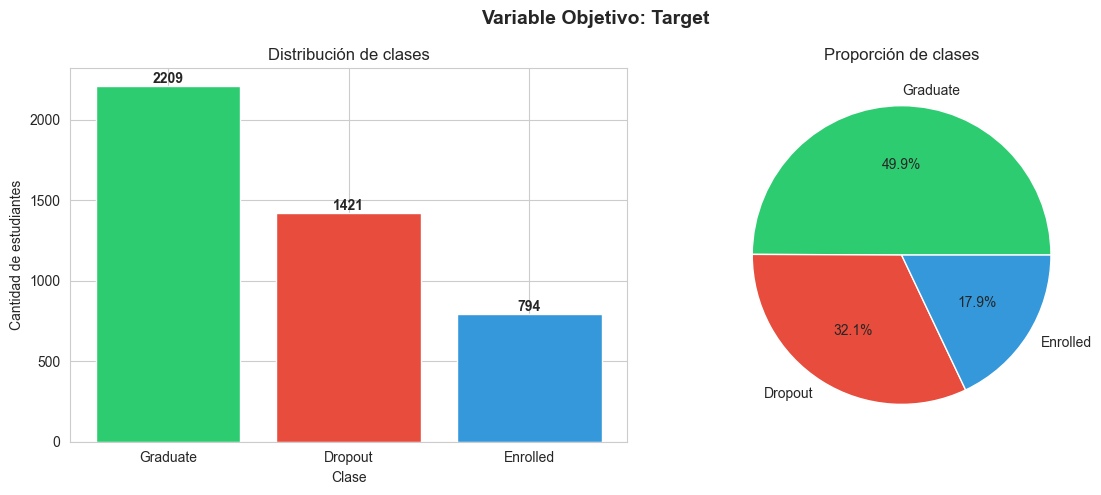

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [4]:
# Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras
conteo = df['Target'].value_counts()
axes[0].bar(conteo.index, conteo.values, color=['#2ecc71', '#e74c3c', '#3498db'])
axes[0].set_title('Distribución de clases')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Cantidad de estudiantes')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Gráfico de torta
axes[1].pie(conteo.values, labels=conteo.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c', '#3498db'])
axes[1].set_title('Proporción de clases')

plt.suptitle('Variable Objetivo: Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(conteo)

#### Interpretación

El dataset presenta un desbalance de clases considerable. La clase 
**Graduate** domina con un 49.9% de los registros, seguida de **Dropout** 
con 32.1% y **Enrolled** con apenas 17.9%.

Este desbalance es relevante porque un modelo que predijera "Graduate" 
para todos los estudiantes obtendría un 49.9% de accuracy sin haber 
aprendido nada útil, casi la mitad de aciertos garantizados por la 
distribución del dataset, no por el aprendizaje del modelo. Esto hace 
que el accuracy no sea una métrica confiable para evaluar el desempeño 
en este problema.

Por esta razón se tomarán dos decisiones técnicas:
- Se utilizará el **F1-score macro** como métrica principal, ya que 
  evalúa el desempeño en cada clase por separado con igual peso, 
  independientemente de su frecuencia.
- Se aplicará **class_weight='balanced'** durante el entrenamiento, 
  para que los modelos no aprendan a favorecer la clase mayoritaria.

#### Estadísticas Descriptivas

Para comprender el comportamiento general de las variables numéricas 
del dataset, se analizan sus estadísticas descriptivas básicas. Esto 
permite identificar rangos de valores, posibles outliers y variables 
con poca variabilidad que podrían no aportar información útil al modelo.

In [5]:
df.describe().round(2)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,...,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00
mean,1.18,18.67,1.73,8856.64,0.89,4.58,132.61,1.87,19.56,22.28,...,0.14,0.54,6.23,8.06,4.44,10.23,0.15,11.57,1.23,0.00
std,0.61,17.48,1.31,2063.57,0.31,10.22,13.19,6.91,15.60,15.34,...,0.69,1.92,2.20,3.95,3.01,5.21,0.75,2.66,1.38,2.27
min,1.00,1.00,0.00,33.00,0.00,1.00,95.00,1.00,1.00,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7.60,-0.80,-4.06
25%,1.00,1.00,1.00,9085.00,1.00,1.00,125.00,1.00,2.00,3.00,...,0.00,0.00,5.00,6.00,2.00,10.75,0.00,9.40,0.30,-1.70
50%,1.00,17.00,1.00,9238.00,1.00,1.00,133.10,1.00,19.00,19.00,...,0.00,0.00,6.00,8.00,5.00,12.20,0.00,11.10,1.40,0.32
75%,1.00,39.00,2.00,9556.00,1.00,1.00,140.00,1.00,37.00,37.00,...,0.00,0.00,7.00,10.00,6.00,13.33,0.00,13.90,2.60,1.79
max,6.00,57.00,9.00,9991.00,1.00,43.00,190.00,109.00,44.00,44.00,...,12.00,19.00,23.00,33.00,20.00,18.57,12.00,16.20,3.70,3.51


#### Interpretación

El análisis descriptivo revela varios aspectos importantes del dataset:

**Valores nulos:** todas las columnas presentan 4,424 registros completos,
confirmando que el dataset no contiene valores nulos.

**Variables con baja variabilidad:** algunas variables presentan un valor 
dominante en la mayoría de registros, lo que podría limitar su capacidad 
predictiva. Los casos más extremos son `Educational special needs` (98.8%), 
`Nacionality` (97.5%) e `International` (97.5%). Estas variables serán 
analizadas en detalle durante el preprocesamiento para evaluar si deben 
ser eliminadas.

**Variables con códigos numéricos:** columnas como `Course`, `Application mode` 
y `Marital status` contienen códigos numéricos que representan categorías, 
no valores continuos. Esto debe considerarse durante el preprocesamiento 
para tratarlas correctamente.

**Variables económicas:** `GDP` presenta valores negativos y `Inflation rate` 
muestra alta variación, lo cual es esperado dado que reflejan condiciones 
macroeconómicas reales del período de estudio.

#### Distribución de Variables Numéricas Continuas

Se analizan las distribuciones de las variables numéricas continuas 
del dataset para identificar asimetrías, outliers y rangos de valores. 
Esto informa las decisiones de escalamiento durante el preprocesamiento.

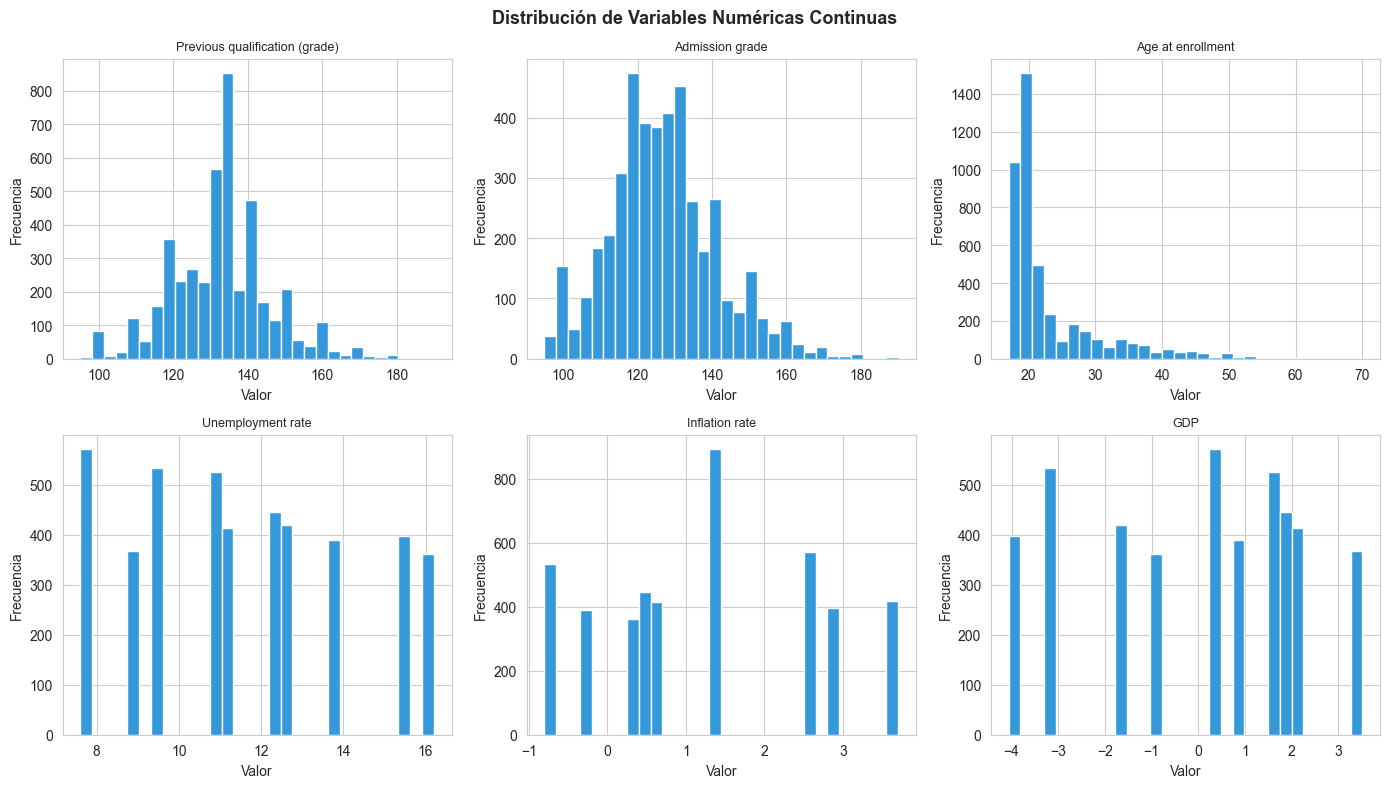

In [15]:
# Variables numéricas continuas generales
continuas = ['Previous qualification (grade)', 'Admission grade',
             'Age at enrollment', 'Unemployment rate', 
             'Inflation rate', 'GDP']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(continuas):
    axes[i].hist(df[col], bins=30, color='#3498db', edgecolor='white')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de Variables Numéricas Continuas', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Interpretación

**Notas de admisión y cualificación previa:** ambas presentan distribuciones 
aproximadamente normales concentradas entre 120 y 150, lo que sugiere 
un proceso de admisión con criterios consistentes. La similitud entre 
ambas distribuciones indica que los estudiantes ingresan con un perfil 
académico previo relativamente homogéneo.

**Edad al matricularse:** la distribución está fuertemente concentrada 
entre 17 y 25 años con una cola larga hacia edades mayores. La presencia 
de estudiantes mayores de 40 años podría representar un perfil con 
dinámicas de abandono distintas, asociadas a responsabilidades laborales 
o familiares.

**Variables macroeconómicas (Unemployment rate, Inflation rate, GDP):** 
las tres presentan distribuciones discretas con pocos valores únicos. 
Esto se debe a que reflejan el contexto económico del país en períodos 
específicos — varios estudiantes comparten el mismo valor por haber 
ingresado en el mismo año. Dado que sus escalas son muy diferentes 
entre sí, estas variables requerirán escalamiento durante el 
preprocesamiento.

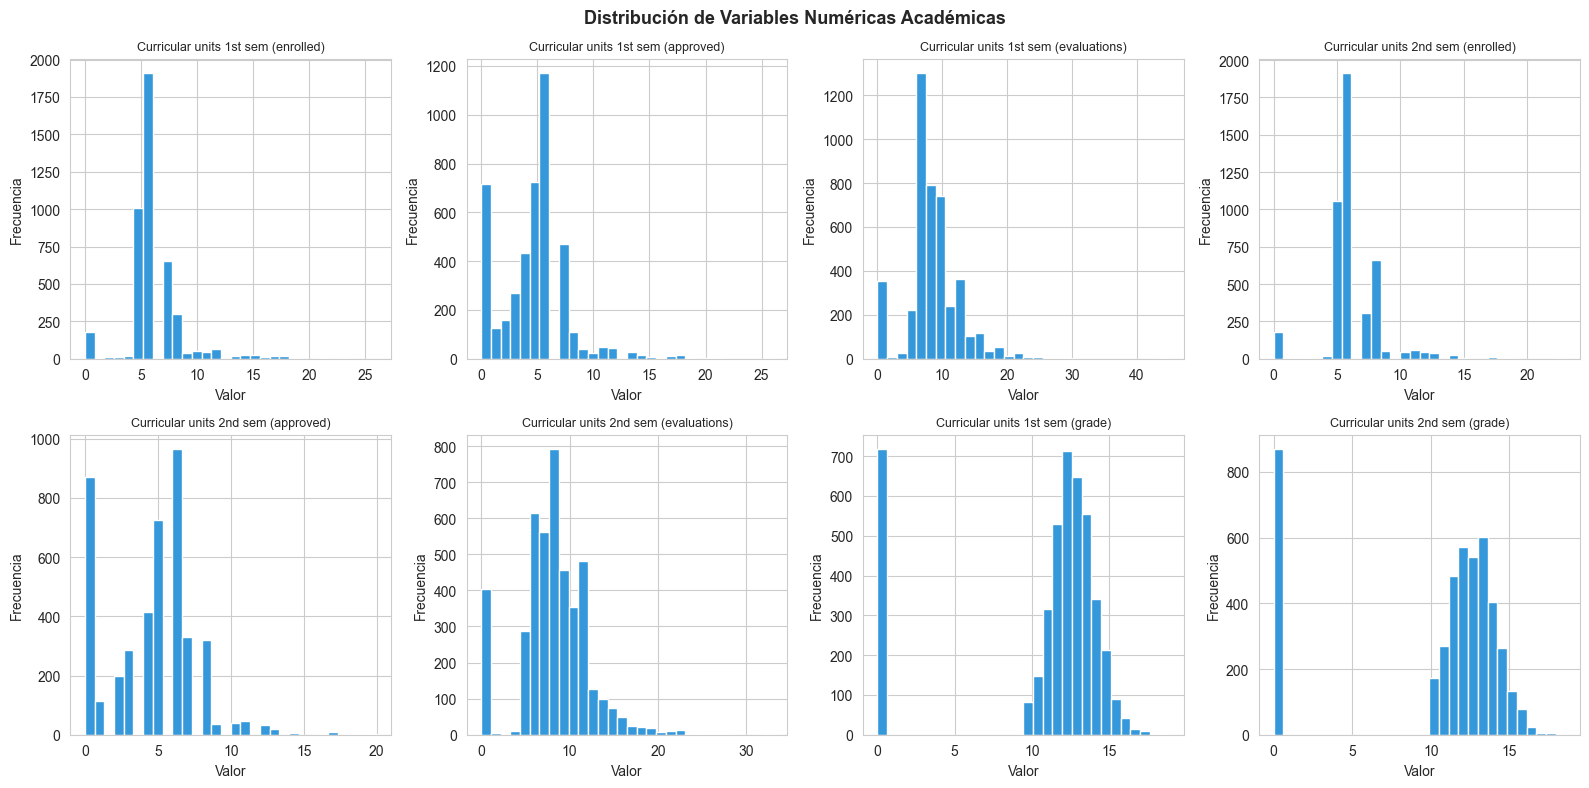

In [14]:
academicas = [
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 1st sem (grade)',
             'Curricular units 2nd sem (grade)'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(academicas):
    axes[i].hist(df[col], bins=30, color='#3498db', edgecolor='white')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de Variables Numéricas Académicas', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Interpretación

**Unidades matriculadas (enrolled):** tanto en el primer como en el 
segundo semestre, la mayoría de estudiantes se matricula en 6 materias, 
con una distribución similar entre ambos semestres. Esto sugiere una 
carga académica estándar para la mayoría.

**Unidades aprobadas (approved):** esta es la variable más reveladora. 
Se observan dos grupos claramente distintos, un grupo que aprueba 
entre 5 y 6 materias, y un grupo significativo con 0 materias aprobadas. 
Esta bimodalidad sugiere una división clara entre estudiantes que 
avanzan normalmente y estudiantes en riesgo de abandono. En el segundo 
semestre el pico en 0 es proporcionalmente mayor, lo que podría indicar 
que quienes no aprobaron en el primero tampoco logran recuperarse.

**Unidades evaluadas (evaluations):** la mayoría fue evaluada entre 
8 y 10 veces, sin embargo el pico inicial en valores bajos sugiere 
estudiantes que dejaron de presentarse a evaluaciones, comportamiento 
consistente con abandono temprano.

**Notas del semestre (grade):** el pico prominente en 0 confirma lo 
observado en approved, un grupo importante de estudiantes termina 
el semestre sin ninguna nota aprobatoria. Estas variables junto con 
approved serán probablemente las más predictivas para el modelo.

#### Relación entre Variables Académicas y la Variable Objetivo

Se analiza cómo se distribuyen las variables académicas según la 
situación final del estudiante. Esto permite identificar qué variables 
tienen mayor capacidad para discriminar entre las tres clases y 
orientar las decisiones de modelado.

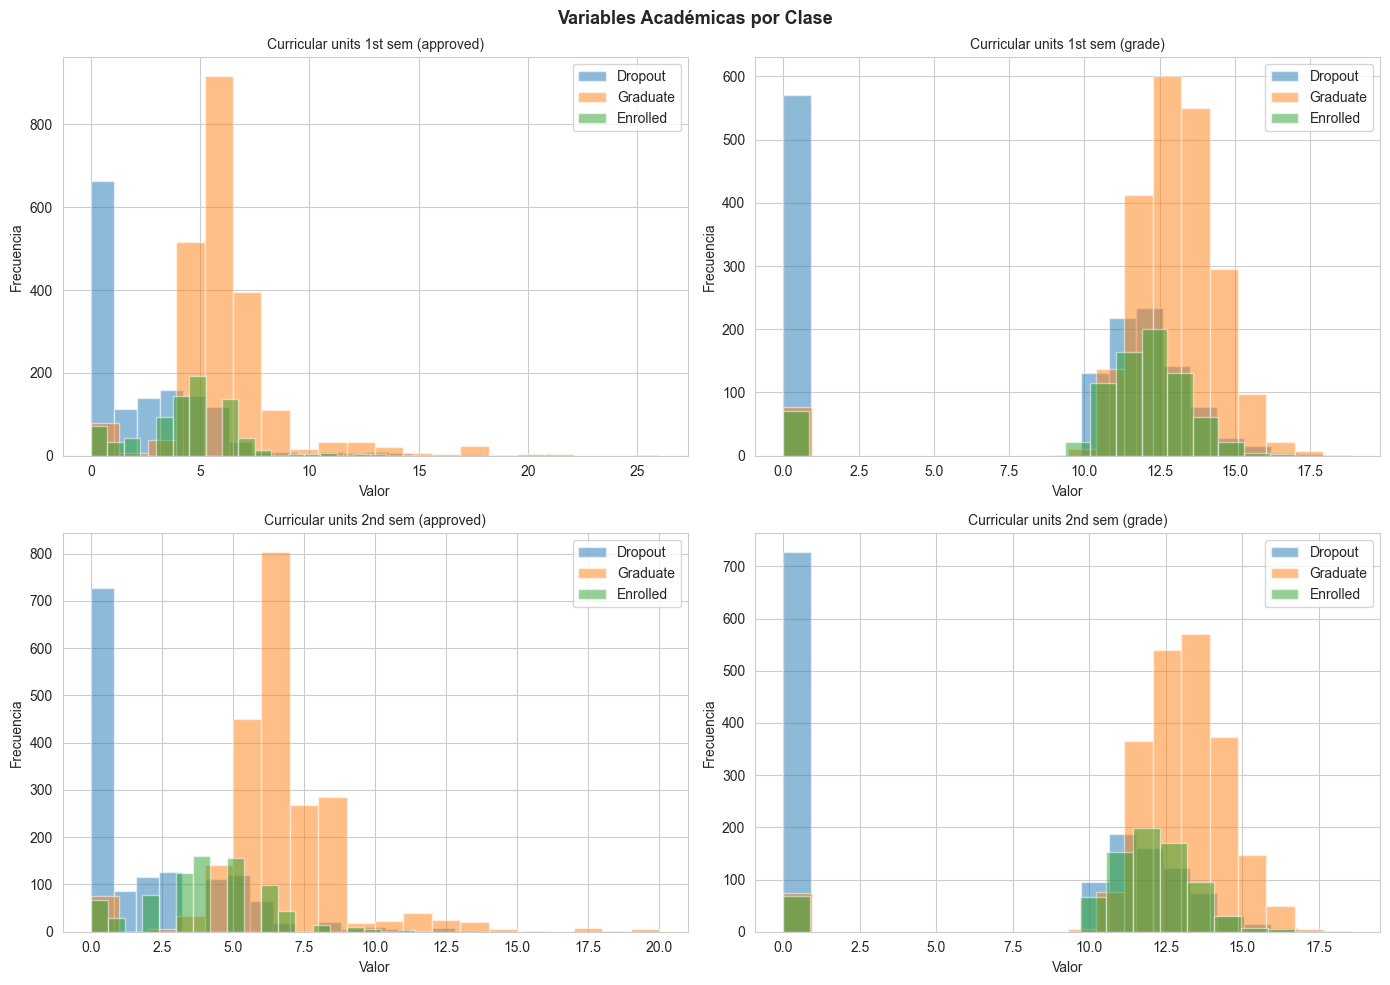

In [18]:
academicas_target = [
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(academicas_target):
    for target in df['Target'].unique():
        subset = df[df['Target'] == target][col]
        axes[i].hist(subset, bins=20, alpha=0.5, label=target)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend()

plt.suptitle('Variables Académicas por Clase', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()